Silakan upload file Social_Network_Ads.csv


Saving Social_Network_Ads.csv to Social_Network_Ads.csv

File yang tersedia di Colab:
['.config', 'Social_Network_Ads.csv', 'sample_data']

Dataset berhasil dimuat!

5 DATA PERTAMA
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

STATIS

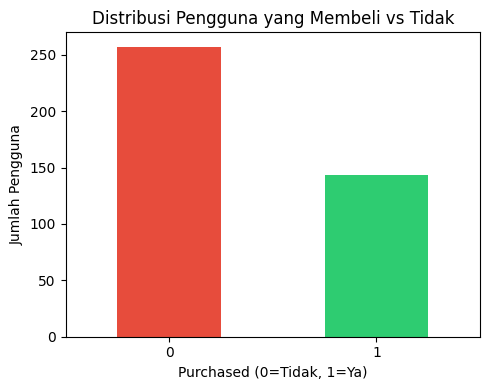

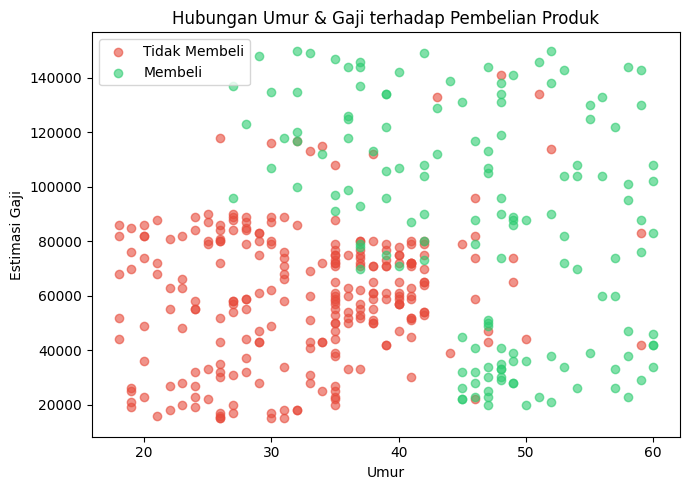

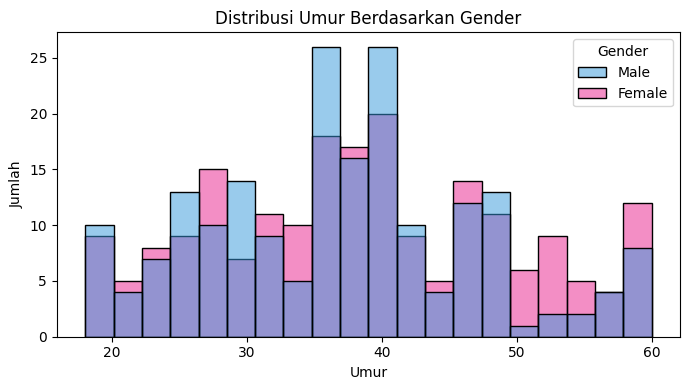


DATA SETELAH PREPROCESSING
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0

Fitur yang digunakan : ['Gender', 'Age', 'EstimatedSalary']
Jumlah Fitur         : 3
Jumlah Data          : 400

Data sebelum normalisasi (3 baris pertama):
   Gender  Age  EstimatedSalary
0       1   19            19000
1       1   35            20000
2       0   26            43000

Data sesudah normalisasi (3 baris pertama):
     Gender       Age  EstimatedSalary
0  1.020204 -1.781797        -1.490046
1  1.020204 -0.253587        -1.460681
2 -0.980196 -1.113206        -0.785290

Jumlah Data Training : 320 baris
Jumlah Data Testing  : 80 baris

Model KNN berhasil dilatih dengan n_neighbors=5

Hasil Prediksi (10 data pertama):
Prediksi : [1 1 0 1 0 0 1 0 0 0]
Aktual   : [0 1 0 1 0 0 1 0 0 0]

AKURASI MO

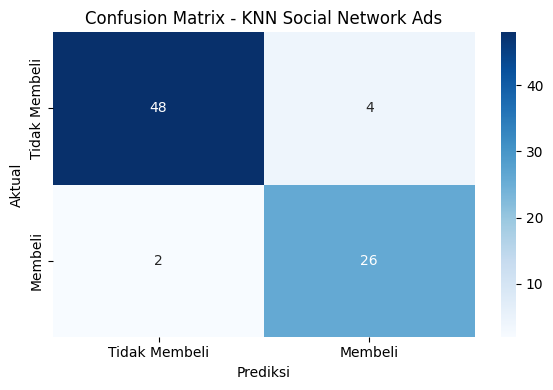

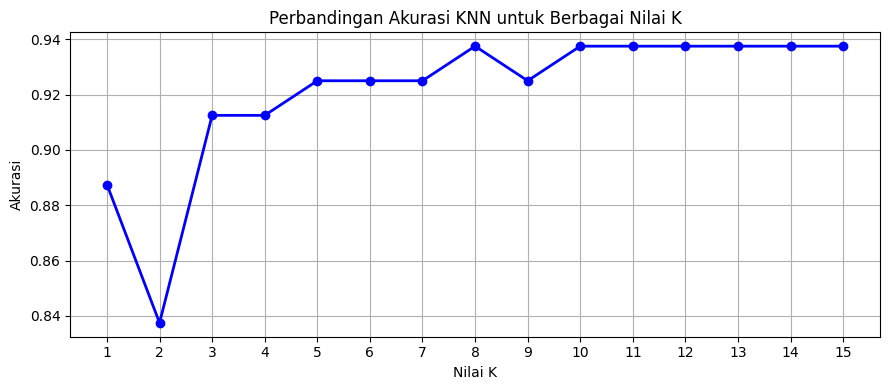


Nilai K Terbaik : 8
Akurasi Terbaik : 93.75%

PREDIKSI PENGGUNA BARU
Gender         : Laki-laki
Umur           : 35 tahun
Estimasi Gaji  : 200.000
Hasil Prediksi : MEMBELI produk ✅
Probabilitas   : Tidak Beli=0.0%, Beli=100.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# Nama Dataset : Social Network Ads
# Link Kaggle  : https://www.kaggle.com/datasets/rakeshrau/social-network-ads
# Tujuan       : Memprediksi apakah pengguna media sosial akan membeli produk berdasarkan iklan

import pandas as pd   # Untuk membuat dan mengolah DataFrame
import numpy as np    # Untuk operasi matematika dan array
import matplotlib.pyplot as plt  # Untuk membuat grafik/visualisasi
import seaborn as sns   # Untuk visualisasi statistik yang lebih menarik

from sklearn.model_selection import train_test_split  # Membagi data train & test
from sklearn.neighbors import KNeighborsClassifier    # Model KNN
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Normalisasi & encoding data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # evaluasi model

# Upload file CSV
from google.colab import files
print("Silakan upload file Social_Network_Ads.csv")
uploaded = files.upload()    # Menampilkan tombol upload file dari komputer

# Cek file berhasil terupload
import os
print("\nFile yang tersedia di Colab:")
print(os.listdir('/content'))   # Menampilkan daftar file di folder Colab

# Membaca file CSV menjadi DataFrame
df = pd.read_csv('Social_Network_Ads.csv')
print("\nDataset berhasil dimuat!")

# Menampilkan 5 baris pertama untuk melihat struktur data
print("\n" + "=" * 50)
print("5 DATA PERTAMA")
print("=" * 50)
print(df.head())

# Menampilkan informasi tipe data dan jumlah nilai non-null tiap kolom
print("\n" + "=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(df.info())

# Menampilkan statistik deskriptif (mean, min, max, std, dll)
print("\n" + "=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
print(df.describe())

# Mengecek apakah ada nilai kosong (missing value) di setiap kolom
print("\n" + "=" * 50)
print("CEK MISSING VALUE")
print("=" * 50)
print(df.isnull().sum())

# Menampilkan jumlah data per kelas target (0=Tidak Membeli, 1=Membeli)
print("\n" + "=" * 50)
print("DISTRIBUSI TARGET (Purchased)")
print("=" * 50)
print(df['Purchased'].value_counts())
print("\n0 = Tidak Membeli")
print("1 = Membeli")

# Grafik batang distribusi target (berapa yang membeli dan tidak)
plt.figure(figsize=(5, 4))
df['Purchased'].value_counts().plot(
    kind='bar',
    color=['#e74c3c', '#2ecc71']  # Merah=tidak membeli, hijau=membeli
)
plt.title('Distribusi Pengguna yang Membeli vs Tidak')
plt.xlabel('Purchased (0=Tidak, 1=Ya)')
plt.ylabel('Jumlah Pengguna')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Grafik scatter untuk melihat pola hubungan umur & gaji terhadap keputusan beli
plt.figure(figsize=(7, 5))
colors = {0: '#e74c3c', 1: '#2ecc71'}
for label, group in df.groupby('Purchased'):
    plt.scatter(
        group['Age'],
        group['EstimatedSalary'],
        label=f"{'Membeli' if label == 1 else 'Tidak Membeli'}",
        color=colors[label],
        alpha=0.6
    )
plt.title('Hubungan Umur & Gaji terhadap Pembelian Produk')
plt.xlabel('Umur')
plt.ylabel('Estimasi Gaji')
plt.legend()
plt.tight_layout()
plt.show()

# Histogram distribusi umur berdasarkan gender
plt.figure(figsize=(7, 4))
sns.histplot(
    data=df,
    x='Age',
    hue='Gender',   # Warna berbeda untuk Male dan Female
    bins=20,        # Jumlah kelompok umur
    palette=['#3498db', '#e91e8c']  # Biru=laki-laki, pink=perempuan
)
plt.title('Distribusi Umur Berdasarkan Gender')
plt.xlabel('Umur')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

# Mengubah kolom Gender dari teks menjadi angka (Male=1, Female=0)
# Karena model machine learning tidak bisa memproses teks
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Menghapus kolom User ID karena tidak relevan untuk prediksi
df = df.drop('User ID', axis=1)

print("\n" + "=" * 50)
print("DATA SETELAH PREPROCESSING")
print("=" * 50)
print(df.head())

# Memisahkan fitur (x) dan targer (y)
X = df.drop('Purchased', axis=1)  # Fitur input: Gender, Age, EstimatedSalary
y = df['Purchased']               # Target output: 0=Tidak Membeli, 1=Membeli

print(f"\nFitur yang digunakan : {X.columns.tolist()}")
print(f"Jumlah Fitur         : {X.shape[1]}")
print(f"Jumlah Data          : {X.shape[0]}")

# StandardScaler mengubah data agar memiliki mean=0 dan std=1
# Penting untuk KNN karena algoritma ini berbasis jarak
# Tanpa normalisasi, fitur dengan nilai besar (gaji) akan mendominasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # Fit=hitung mean&std, transform=ubah nilainya

print("\nData sebelum normalisasi (3 baris pertama):")
print(X.head(3))

print("\nData sesudah normalisasi (3 baris pertama):")
print(pd.DataFrame(X_scaled, columns=X.columns).head(3))

# Split data
# Test_size=0.2 : 20% untuk testing, 80% untuk training
# Random_state=42 : hasil pembagian selalu sama setiap dijalankan
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"\nJumlah Data Training : {X_train.shape[0]} baris")
print(f"Jumlah Data Testing  : {X_test.shape[0]} baris")

# Membuat dan melatih model KNN
# n_neighbors=5 : model melihat 5 tetangga terdekat untuk menentukan kelas
# Semakin kecil k : model lebih sensitif (overfitting)
# Semakin besar k : model lebih umum (underfitting)
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)   # Melatih model dengan data training

print("\nModel KNN berhasil dilatih dengan n_neighbors=5")

# Prediksi
y_prediksi = model_knn.predict(X_test)  # Memprediksi kelas dari data testing

print("\nHasil Prediksi (10 data pertama):")
print("Prediksi :", y_prediksi[:10])    # Hasil prediksi model
print("Aktual   :", y_test.values[:10]) # Nilai asli dari data testing


# Evaluasi
akurasi = accuracy_score(y_test, y_prediksi)  # Hitung persentase prediksi benar

print("\n" + "=" * 50)
print(f"AKURASI MODEL KNN (k=5) : {akurasi * 100:.2f}%")
print("=" * 50)

# Classification Report : precision, recall, f1-score per kelas
# Precision : dari semua prediksi positif, berapa yang benar?
# Recall    : dari semua data positif asli, berapa yang terdeteksi?
# F1-Score  : keseimbangan antara precision dan recall
print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_test, y_prediksi,
    target_names=['Tidak Membeli', 'Membeli']
))

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_prediksi)

# Visualisasi confusion matrix menggunakan heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,   # Tampilkan angka di setiap kotak
    fmt='d',      # Format angka bulat (integer)
    cmap='Blues', # Warna biru
    xticklabels=['Tidak Membeli', 'Membeli'],
    yticklabels=['Tidak Membeli', 'Membeli']
)
plt.title('Confusion Matrix - KNN Social Network Ads')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

# Mencoba nilai k dari 1 sampai 15 untuk menemukan akurasi tertinggi
daftar_k       = range(1, 16)
daftar_akurasi = []

for k in daftar_k:
    knn_coba = KNeighborsClassifier(n_neighbors=k)  # Buat model dengan nilai k berbeda
    knn_coba.fit(X_train, y_train)           # Latih model
    pred_coba = knn_coba.predict(X_test)     # Prediksi
    daftar_akurasi.append(accuracy_score(y_test, pred_coba))  # Simpan akurasi

plt.figure(figsize=(9, 4))
plt.plot(daftar_k, daftar_akurasi, marker='o', color='blue', linewidth=2)
plt.title('Perbandingan Akurasi KNN untuk Berbagai Nilai K')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.xticks(daftar_k)
plt.grid(True)
plt.tight_layout()
plt.show()

# Menampilkan nilai k dan akurasi terbaik
k_terbaik       = daftar_k[daftar_akurasi.index(max(daftar_akurasi))]
akurasi_terbaik = max(daftar_akurasi)
print(f"\nNilai K Terbaik : {k_terbaik}")
print(f"Akurasi Terbaik : {akurasi_terbaik * 100:.2f}%")

# Prediksi data baru
print("\n" + "=" * 50)
print("PREDIKSI PENGGUNA BARU")
print("=" * 50)

# Contoh: Laki-laki (1), Umur 35 tahun, Gaji 200.000
data_baru        = np.array([[1, 35, 200000]])
data_baru_scaled = scaler.transform(data_baru)

hasil        = model_knn.predict(data_baru_scaled)
probabilitas = model_knn.predict_proba(data_baru_scaled)

print(f"Gender         : Laki-laki")
print(f"Umur           : 35 tahun")
print(f"Estimasi Gaji  : 200.000")
print(f"Hasil Prediksi : {'MEMBELI produk ✅' if hasil[0] == 1 else 'TIDAK MEMBELI produk ❌'}")
print(f"Probabilitas   : Tidak Beli={probabilitas[0][0]*100:.1f}%, Beli={probabilitas[0][1]*100:.1f}%")